In [31]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  


In [33]:
df = pd.read_csv("C:\\Users\\papaa\\OneDrive\\Desktop\\PORTFOLIO-DATASETS\\telco-customer-churn-analysis\\Data\\Telco_customer_churn.csv")  # Load the dataset  
df.head()  # Display the first 5 rows  


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [36]:
df.info()  # Check column types and missing values  
df.describe()  # Summary statistics  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [37]:
df.isnull().sum()  # Check for missing values  
df.dropna(inplace=True)  # Remove missing values  


In [38]:
print(df.columns)


Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


In [39]:
print(df[['Churn Label', 'Churn Value', 'Churn Score', 'Churn Reason']].head())


  Churn Label  Churn Value  Churn Score                   Churn Reason
0         Yes            1           86   Competitor made better offer
1         Yes            1           67                          Moved
2         Yes            1           86                          Moved
3         Yes            1           84                          Moved
4         Yes            1           89  Competitor had better devices


In [40]:
df.columns = df.columns.str.strip()  # Remove spaces before/after names
df.columns = df.columns.str.lower()  # Convert to lowercase

print(df.columns)  # Check the cleaned column names


Index(['customerid', 'count', 'country', 'state', 'city', 'zip code',
       'lat long', 'latitude', 'longitude', 'gender', 'senior citizen',
       'partner', 'dependents', 'tenure months', 'phone service',
       'multiple lines', 'internet service', 'online security',
       'online backup', 'device protection', 'tech support', 'streaming tv',
       'streaming movies', 'contract', 'paperless billing', 'payment method',
       'monthly charges', 'total charges', 'churn label', 'churn value',
       'churn score', 'cltv', 'churn reason'],
      dtype='object')


In [41]:
for col in df.columns:
    if 'churn' in col.lower():
        print(f"Possible churn column: '{col}'")




Possible churn column: 'churn label'
Possible churn column: 'churn value'
Possible churn column: 'churn score'
Possible churn column: 'churn reason'


In [42]:
print(df.head())


   customerid  count        country       state         city  zip code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 lat long   latitude   longitude  gender  ...        contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  paperless billing             payment method  monthly charges tota

In [52]:
df.rename(columns={'Churn Value': 'Churn'}, inplace=True)


In [55]:
print(df.columns.tolist())


['customerid', 'count', 'country', 'state', 'city', 'zip code', 'lat long', 'latitude', 'longitude', 'gender', 'senior citizen', 'partner', 'dependents', 'tenure months', 'phone service', 'multiple lines', 'internet service', 'online security', 'online backup', 'device protection', 'tech support', 'streaming tv', 'streaming movies', 'contract', 'paperless billing', 'payment method', 'monthly charges', 'total charges', 'churn label', 'churn value', 'churn score', 'cltv', 'churn reason']


In [56]:
# Rename for convenience
df.rename(columns={'churn value': 'churn'}, inplace=True)

# Check value counts now
print(df['churn'].value_counts())




1    1869
Name: churn, dtype: int64


In [47]:
print(df.columns)


Index(['customerid', 'count', 'country', 'state', 'city', 'zip code',
       'lat long', 'latitude', 'longitude', 'gender', 'senior citizen',
       'partner', 'dependents', 'tenure months', 'phone service',
       'multiple lines', 'internet service', 'online security',
       'online backup', 'device protection', 'tech support', 'streaming tv',
       'streaming movies', 'contract', 'paperless billing', 'payment method',
       'monthly charges', 'total charges', 'churn label', 'churn value',
       'churn score', 'cltv', 'churn reason'],
      dtype='object')


In [53]:
df = df.loc[:, ~df.columns.duplicated()]  # Removes duplicate columns
print(df.columns)  # Check again


Index(['customerid', 'count', 'country', 'state', 'city', 'zip code',
       'lat long', 'latitude', 'longitude', 'gender', 'senior citizen',
       'partner', 'dependents', 'tenure months', 'phone service',
       'multiple lines', 'internet service', 'online security',
       'online backup', 'device protection', 'tech support', 'streaming tv',
       'streaming movies', 'contract', 'paperless billing', 'payment method',
       'monthly charges', 'total charges', 'churn label', 'churn value',
       'churn score', 'cltv', 'churn reason'],
      dtype='object')


In [54]:
print(df.isnull().sum())  # Shows missing values per column


customerid           0
count                0
country              0
state                0
city                 0
zip code             0
lat long             0
latitude             0
longitude            0
gender               0
senior citizen       0
partner              0
dependents           0
tenure months        0
phone service        0
multiple lines       0
internet service     0
online security      0
online backup        0
device protection    0
tech support         0
streaming tv         0
streaming movies     0
contract             0
paperless billing    0
payment method       0
monthly charges      0
total charges        0
churn label          0
churn value          0
churn score          0
cltv                 0
churn reason         0
dtype: int64


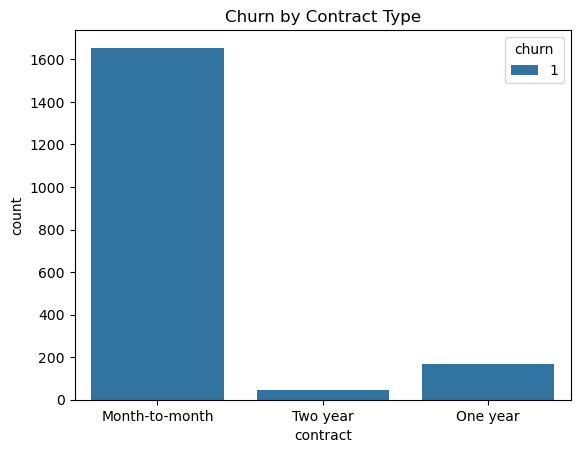

In [64]:
sns.countplot(x='contract', hue='churn', data=df)
plt.title("Churn by Contract Type")

# Save the figure
plt.savefig("C:\\Users\\papaa\\OneDrive\\Desktop\\PORTFOLIO-DATASETS\\telco-customer-churn-analysis\\Images\\contract_churn_plot.png")

plt.show()



In [44]:
df = pd.get_dummies(df, drop_first=True)



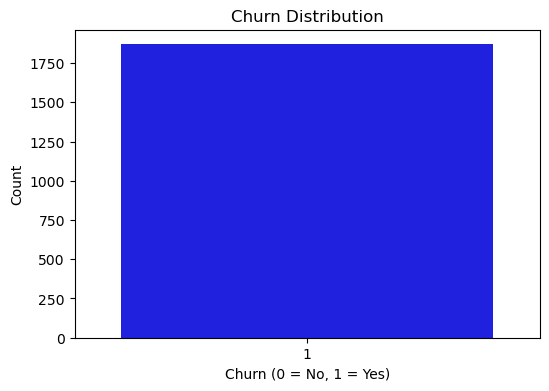

1    100.0
Name: churn, dtype: float64


<Figure size 640x480 with 0 Axes>

In [66]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['churn'], palette=['blue', 'red'])
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()
# Save the figure
plt.savefig("C:\\Users\\papaa\\OneDrive\\Desktop\\PORTFOLIO-DATASETS\\telco-customer-churn-analysis\\Images\\contract_churn_plot.png")
# Print percentage values
print(df['churn'].value_counts(normalize=True) * 100)


In [47]:
print(df.columns)


Index(['count', 'latitude', 'longitude', 'tenure months', 'monthly charges',
       'churn', 'cltv', 'gender_Male', 'senior citizen_Yes', 'partner_Yes',
       ...
       'total charges_98.5', 'total charges_987.95', 'total charges_989.45',
       'total charges_99.75', 'total charges_990.85', 'total charges_990.9',
       'total charges_994.55', 'total charges_994.8', 'total charges_997.65',
       'total charges_999.45'],
      dtype='object', length=1765)


In [49]:
[col for col in df.columns if 'contract' in col.lower()]


['contract_One year', 'contract_Two year']

In [50]:
df['contract_Month-to-month'] = 1 - (df['contract_One year'] + df['contract_Two year'])


In [51]:
contract_cols = ['contract_Month-to-month', 'contract_One year', 'contract_Two year']
df_melted = df.melt(id_vars=['churn'], value_vars=contract_cols, var_name='Contract Type', value_name='Value')

# Keep only rows where Value == 1 (indicating the customer's contract type)
df_melted = df_melted[df_melted['Value'] == 1]


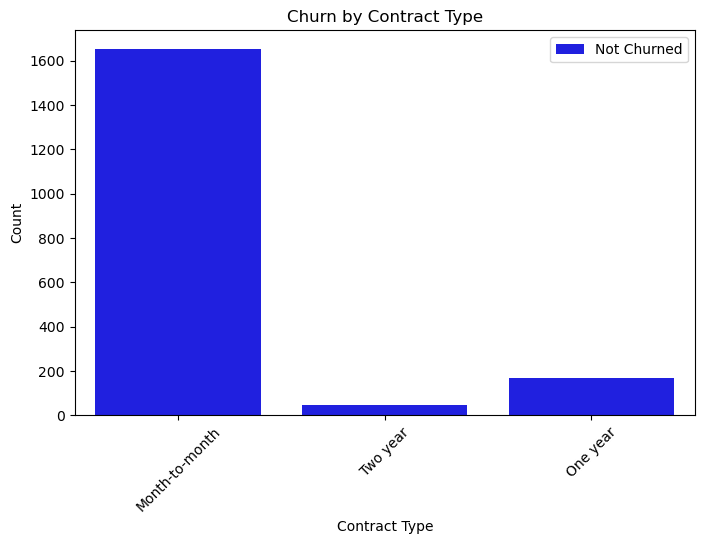

In [71]:
plt.figure(figsize=(8, 5))
sns.countplot(x='contract', hue='churn label', data=df, palette=['blue', 'red'])
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(["Not Churned", "Churned"])
plt.xticks(rotation=45)  # Rotate labels for better readability
# Save the figure
plt.savefig("C:\\Users\\papaa\\OneDrive\\Desktop\\PORTFOLIO-DATASETS\\telco-customer-churn-analysis\\Images\\contract_churn_plot.png")
plt.show()




In [77]:
# Find relevant columns
[col for col in df.columns if 'payment method' in col.lower()]


['payment method']

In [74]:
print([col for col in df.columns if 'payment' in col.lower()])


['payment method']


In [75]:
print([col for col in df.columns if 'payment' in col.lower()])


['payment method']


In [78]:
print(payment_churn.head())
print(payment_churn.dtypes)


   churn  Payment Method                      Count
0    258  payment method  Bank transfer (automatic)
1    232  payment method    Credit card (automatic)
2   1071  payment method           Electronic check
3    308  payment method               Mailed check
churn              int64
Payment Method    object
Count             object
dtype: object


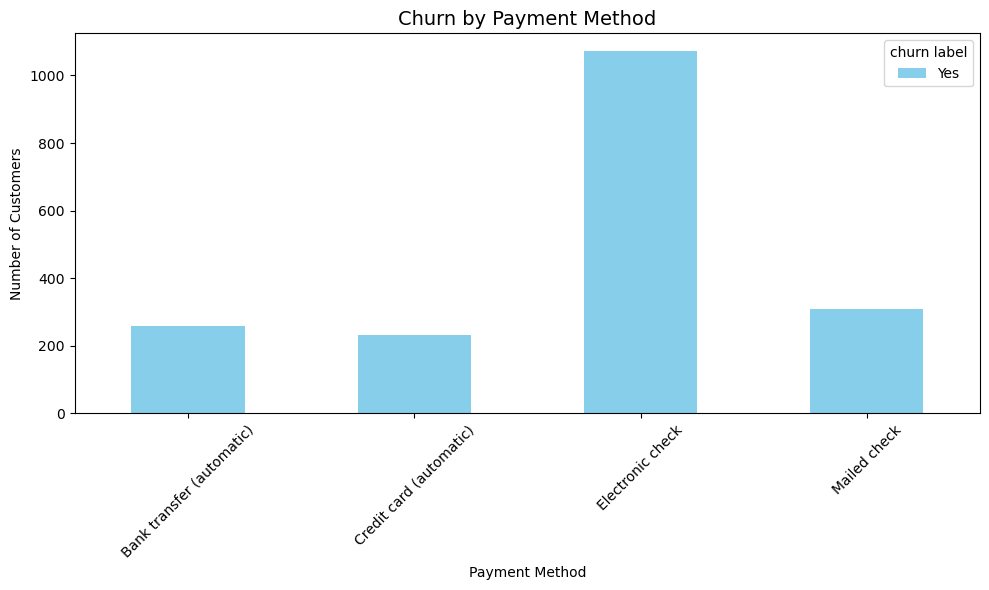

In [81]:
# Plot with custom colors
payment_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['skyblue', 'salmon']  # Custom bright colors
)

# Title and labels
plt.title("Churn by Payment Method", fontsize=14)
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure
plt.savefig("C:\\Users\\papaa\\OneDrive\\Desktop\\PORTFOLIO-DATASETS\\telco-customer-churn-analysis\\Images\\payment_method_churn_plot.png")

plt.show()


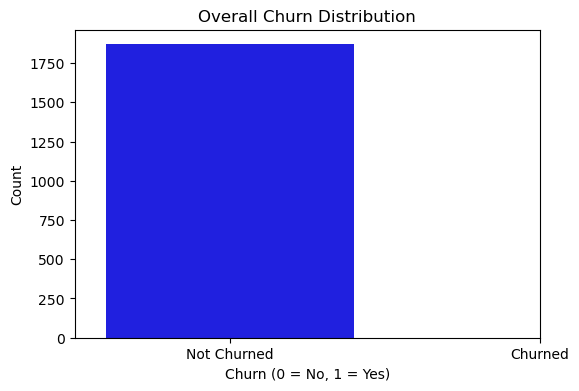

In [58]:
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette=['blue', 'red'])
plt.title("Overall Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Not Churned", "Churned"])
plt.show()


In [60]:
print(df['churn'].unique())


[1]


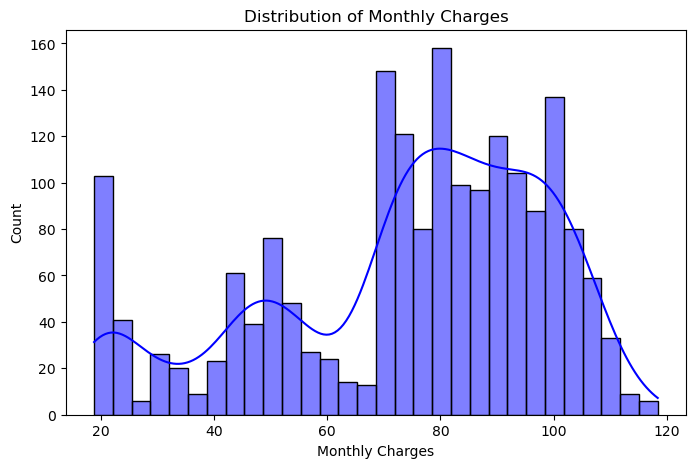

In [61]:
plt.figure(figsize=(8, 5))
sns.histplot(df, x='monthly charges', bins=30, kde=True, color='blue')
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()


In [62]:
print(df['churn'].value_counts())


1    1869
Name: churn, dtype: int64


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns


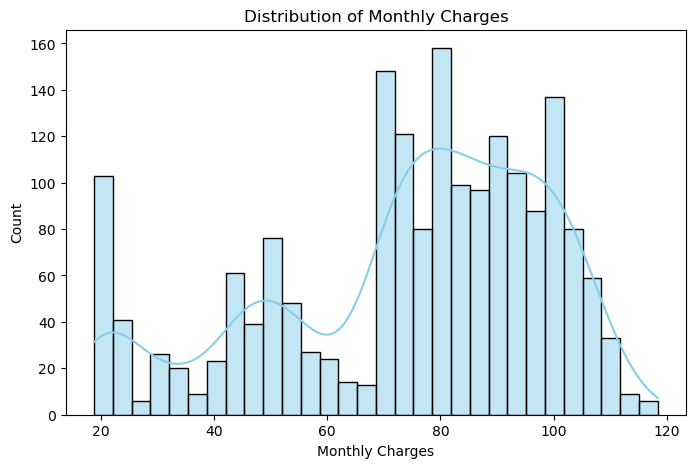

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(df['monthly charges'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()


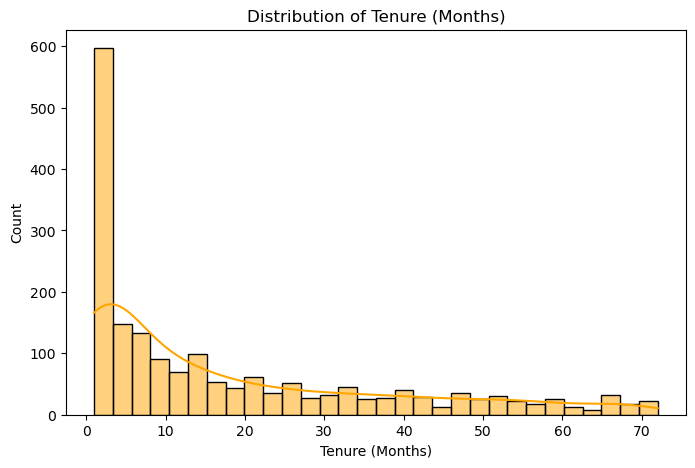

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df['tenure months'], bins=30, kde=True, color='orange')
plt.title("Distribution of Tenure (Months)")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.show()


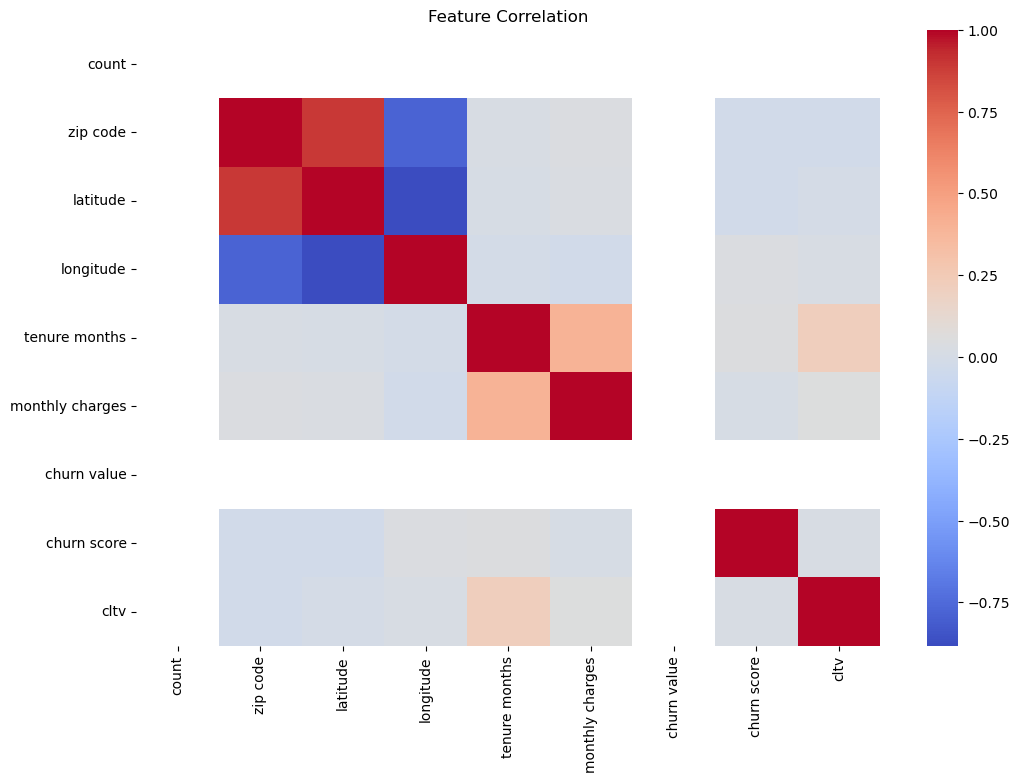

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation")
plt.show()
